In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
import pickle

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


- Run ~1000 small natural image patches in the normative model
- Pick ~200 most activating patches per neuron
- Show full field version and analyze response modulation
- Post results in channel to discuss whether to include in paper

In [2]:
natimgs = load_images(
    crop_size=36,
    n_samples=1_000,
    transform=transforms.Compose(
        [
            transforms.Resize(36),
        ]
    ),
    shuffle=True,
)
natimgs = natimgs - natimgs.mean(axis=0)

In [3]:
exc_images = get_excitatory_images()
vmin = exc_images.min()
vmax = exc_images.max()

In [4]:
exc_images.mean(), exc_images.std()

(-2.1820679693867274e-16, 8.680394793589969)

In [5]:
exc_images.min(), exc_images.max()

(-69.35208333333334, 104.31458333333333)

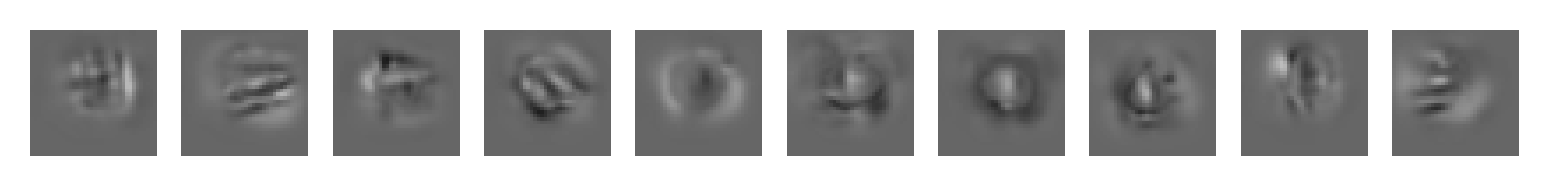

In [21]:
# Take a look at model RFs (G-level)
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [22]:
natimgs.mean(), natimgs.std()

(-2.694799116364232e-16, 61.28360518128976)

In [23]:
exc_images.mean(), exc_images.std()

(-2.1820679693867274e-16, 8.680394793589969)

In [24]:
natimgs_normed = natimgs / exc_images.std()
print(f"natimgs_normed mean: {natimgs_normed.mean()}, std: {natimgs_normed.std()}")

natimgs_normed mean: 3.561485811340749e-17, std: 7.060002066558605


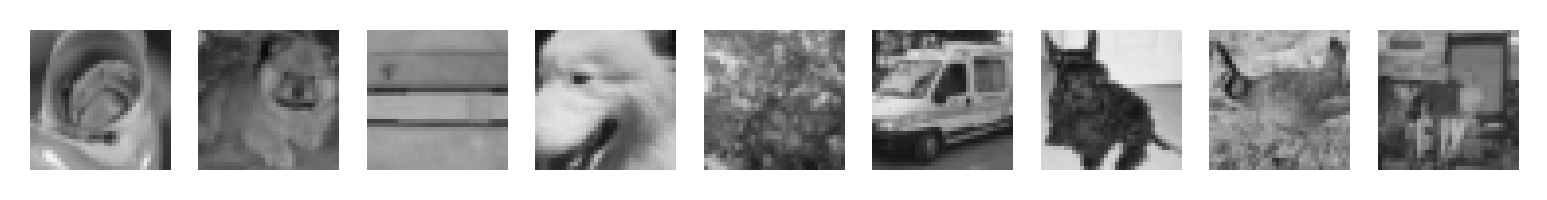

In [25]:
# Take a look at new stimuli
fig, axs = plt.subplots(1, 9, dpi=300)
for ax, stimulus in zip(axs.flatten(), natimgs_normed[9:18]):
    ax.imshow(stimulus, cmap="gray", vmin=natimgs_normed.min(), vmax=natimgs_normed.max())
    ax.axis("off")

### Create "small" images

In [26]:
def get_center_patches(patterns):
    h = patterns.shape[1]
    center_region_start = h // 3
    center_region_end = 2 * h // 3
    stimulus = np.zeros_like(patterns)
    stimulus[:,
        center_region_start:center_region_end,
        center_region_start:center_region_end,
    ] = patterns[:,
        center_region_start:center_region_end,
        center_region_start:center_region_end,
    ].copy()
    return stimulus

In [27]:
small_stimuli = get_center_patches(natimgs_normed)

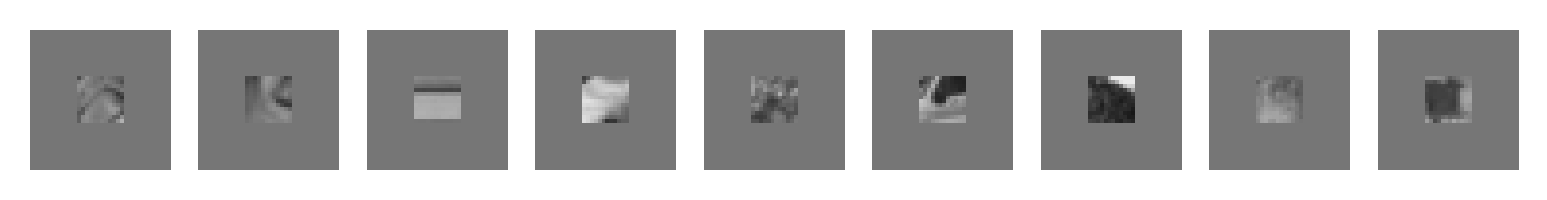

In [29]:
# Take a look at new stimuli
fig, axs = plt.subplots(1, 9, dpi=300)
for ax, stimulus in zip(axs.flatten(), small_stimuli[9:18]):
    ax.imshow(stimulus, cmap="gray", vmin=natimgs_normed.min(), vmax=natimgs_normed.max())
    ax.axis("off")

In [ ]:
small_stimuli[0].shape

(36, 36)

In [ ]:
for idx, stimulus in enumerate(small_stimuli):
    print(f"Processing stimulus {idx + 1}/{len(small_stimuli)}")
    
    idata = model(
        image=stimulus,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    


Only 300 samples in chain.


Processing stimulus 1/1000


Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 41 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
